# Data exploreation on exchange rates

In [22]:
import pandas as pd
import numpy as np

In [35]:
covariate = pd.read_csv("predictor_data.csv")
covariate_exchange_rate = covariate[['Date', "AUD_USD", "CAD_USD", "NZD_USD", "ZAR_USD"]].copy() 

covariate_exchange_rate.head()
covariate_exchange_rate.tail()
covariate_exchange_rate = covariate_exchange_rate.dropna() # drop february data

In [36]:
covariate_exchange_rate.tail()

,Date,AUD_USD,CAD_USD,NZD_USD,ZAR_USD
476,2025-09-01,0.659757,1.383429,0.588419,17.425195
477,2025-10-01,0.654682,1.398768,0.576491,17.272164
478,2025-11-01,0.650172,1.405617,0.565206,17.229661
479,2025-12-01,0.664264,1.379491,0.578691,16.832650
480,2026-01-01,0.679175,1.377080,0.585090,16.262495


In [37]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name=""):
    result = adfuller(series.dropna())
    
    print(f"ADF Test for {name}")
    print(f"Test Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Lags Used: {result[2]}")
    print(f"Observations: {result[3]}")
    print("-" * 40)

# loop through all currencies
cols = ["AUD_USD", "CAD_USD", "NZD_USD", "ZAR_USD"]

for col in cols:
    adf_test(covariate_exchange_rate[col], col)

ADF Test for AUD_USD
Test Statistic: -2.2411
p-value: 0.1917
Lags Used: 2
Observations: 478
----------------------------------------
ADF Test for CAD_USD
Test Statistic: -1.9186
p-value: 0.3234
Lags Used: 1
Observations: 479
----------------------------------------
ADF Test for NZD_USD
Test Statistic: -2.4814
p-value: 0.1201
Lags Used: 1
Observations: 479
----------------------------------------
ADF Test for ZAR_USD
Test Statistic: -0.7069
p-value: 0.8450
Lags Used: 2
Observations: 478
----------------------------------------


In [38]:
# take log differences to achieve stationarity
for col in cols:
    covariate_exchange_rate[f"{col}_ret"] = np.log(covariate_exchange_rate[col]).diff()

# check stationarity again
for col in cols:
    adf_test(covariate_exchange_rate[f"{col}_ret"], f"{col} Returns")

ADF Test for AUD_USD Returns
Test Statistic: -14.5051
p-value: 0.0000
Lags Used: 1
Observations: 478
----------------------------------------
ADF Test for CAD_USD Returns
Test Statistic: -16.5704
p-value: 0.0000
Lags Used: 0
Observations: 479
----------------------------------------
ADF Test for NZD_USD Returns
Test Statistic: -16.3280
p-value: 0.0000
Lags Used: 0
Observations: 479
----------------------------------------
ADF Test for ZAR_USD Returns
Test Statistic: -14.2518
p-value: 0.0000
Lags Used: 1
Observations: 478
----------------------------------------


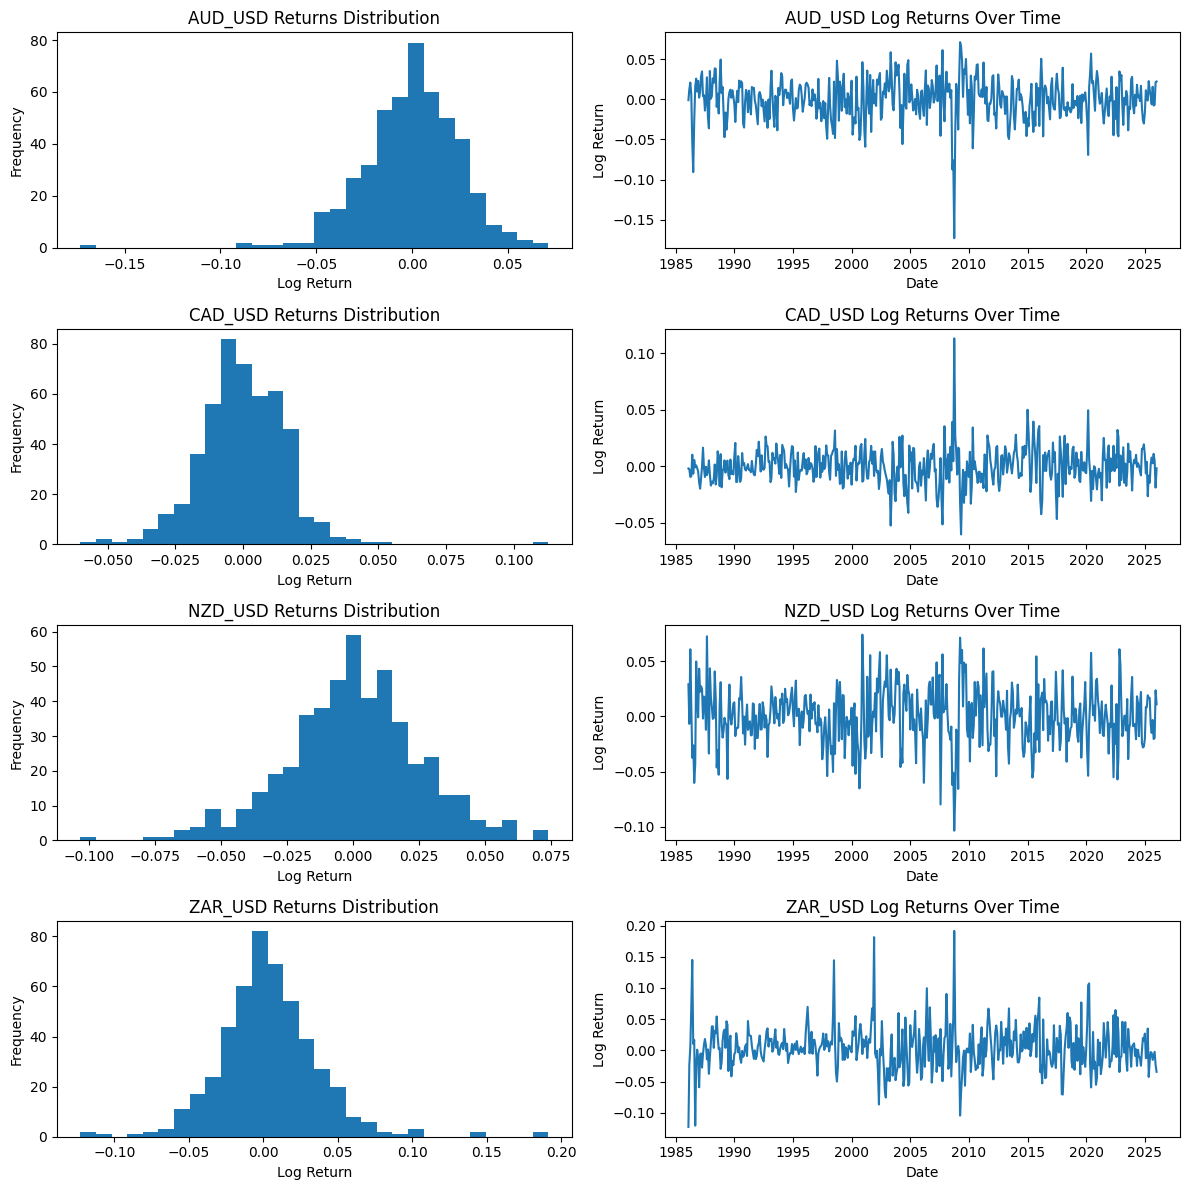

In [39]:
# plot distribution and return for each currency
import matplotlib.pyplot as plt

cols = ["AUD_USD", "CAD_USD", "NZD_USD", "ZAR_USD"]
covariate_exchange_rate['Date'] = pd.to_datetime(covariate_exchange_rate['Date'])

n = len(cols)

fig, axes = plt.subplots(n, 2, figsize=(12, 3 * n))

for i, col in enumerate(cols):
    ret = covariate_exchange_rate[f"{col}_ret"].dropna()
    dates = covariate_exchange_rate["Date"].iloc[-len(ret):]

    # -------------------------
    # LEFT: Distribution
    # -------------------------
    axes[i, 0].hist(ret, bins=30)
    axes[i, 0].set_title(f"{col} Returns Distribution")
    axes[i, 0].set_xlabel("Log Return")
    axes[i, 0].set_ylabel("Frequency")

    # -------------------------
    # RIGHT: Time series
    # -------------------------
    axes[i, 1].plot(dates, ret)
    axes[i, 1].set_title(f"{col} Log Returns Over Time")
    axes[i, 1].set_xlabel("Date")
    axes[i, 1].set_ylabel("Log Return")

plt.tight_layout()
plt.show()

In [41]:
covariate_exchange_rate = covariate_exchange_rate.dropna()
covariate_exchange_rate.head()
covariate_exchange_rate.tail()

,Date,AUD_USD,CAD_USD,NZD_USD,ZAR_USD,AUD_USD_ret,CAD_USD_ret,NZD_USD_ret,ZAR_USD_ret
476,2025-09-01,0.659757,1.383429,0.588419,17.425195,0.015662,0.002685,-0.003248,-0.015405
477,2025-10-01,0.654682,1.398768,0.576491,17.272164,-0.007722,0.011027,-0.020480,-0.008821
478,2025-11-01,0.650172,1.405617,0.565206,17.229661,-0.006912,0.004884,-0.019770,-0.002464
479,2025-12-01,0.664264,1.379491,0.578691,16.832650,0.021442,-0.018762,0.023579,-0.023312
480,2026-01-01,0.679175,1.377080,0.585090,16.262495,0.022200,-0.001749,0.010997,-0.034459


In [45]:
new_covariate_exchange = covariate_exchange_rate[['Date', "AUD_USD_ret", "CAD_USD_ret", "NZD_USD_ret", "ZAR_USD_ret"]].copy()
new_covariate_exchange.head()
len(new_covariate_exchange)
new_covariate_exchange['Date'] = pd.to_datetime(new_covariate_exchange['Date'])

In [44]:
fredmd = pd.read_csv('fredmd.csv')
macro = fredmd[[
    'date',
    "CPIAUCSL",   # CPI
    "TB3MS",      # Treasury bill
    "M1SL",       # M1
    "M2SL"        # M2
]].copy()

macro




,date,CPIAUCSL,TB3MS,M1SL,M2SL
0,1986-01-01,-0.000930,-0.03,-0.009760,-0.001750
1,1986-02-01,-0.005468,-0.01,0.003518,0.000302
2,1986-03-01,-0.003663,-0.50,0.007092,0.003699
3,1986-04-01,0.001811,-0.50,-0.001419,0.001697
4,1986-05-01,0.006429,0.09,0.005246,0.000797
...,...,...,...,...,...
476,2025-09-01,-0.000530,-0.20,0.002021,0.001084
477,2025-10-01,NaN,-0.10,0.000990,-0.000535
478,2025-11-01,NaN,-0.04,-0.003364,-0.002283
479,2025-12-01,NaN,-0.19,0.003410,0.002887


In [46]:
macro.isna().sum()

date        0
CPIAUCSL    3
TB3MS       0
M1SL        0
M2SL        0
dtype: int64

In [48]:
# fill forward missing values for CPIAUCSL
macro['CPIAUCSL'] = macro['CPIAUCSL'].fillna(method='ffill')
macro.tail()

,date,CPIAUCSL,TB3MS,M1SL,M2SL
476,2025-09-01,-0.000530,-0.20,0.002021,0.001084
477,2025-10-01,-0.000530,-0.10,0.000990,-0.000535
478,2025-11-01,-0.000530,-0.04,-0.003364,-0.002283
479,2025-12-01,-0.000530,-0.19,0.003410,0.002887
480,2026-01-01,-0.001266,-0.02,0.001133,-0.000433


In [52]:
# rename columns for merging
macro = macro.rename(columns={'date': 'Date', 
                              'CPIAUCSL': 'CPI', 
                            'TB3MS': 'TB3MS', 
                            'M1SL': 'M1', 
                            'M2SL': 'M2'})
macro['Date'] = pd.to_datetime(macro['Date'])

df_merged = pd.merge(new_covariate_exchange, macro, on='Date', how='inner')
df_merged.head()

,Date,AUD_USD_ret,CAD_USD_ret,NZD_USD_ret,ZAR_USD_ret,CPI,TB3MS,M1,M2
0,1986-02-01,-0.001030,-0.001919,0.029004,-0.122803,-0.005468,-0.01,0.003518,0.000302
1,1986-03-01,0.012299,-0.002406,-0.006743,-0.023616,-0.003663,-0.50,0.007092,0.003699
2,1986-04-01,0.020833,-0.009353,0.060724,0.005213,0.001811,-0.50,-0.001419,0.001697
3,1986-05-01,0.006006,-0.008792,0.009556,0.067115,0.006429,0.09,0.005246,0.000797
4,1986-06-01,-0.054147,0.010266,-0.037406,0.144931,0.000907,0.06,-0.003911,-0.002716


In [61]:
# import wti price data
wti = pd.read_csv('wti_prices.csv')

# take log difference of wti 
wti['wti_ret'] = np.log(wti['WTI_price']).diff()

# drop the first row with NaN log difference
wti = wti.dropna().reset_index(drop=True)

wti.head()
wti['Date'] = pd.to_datetime(wti['Date'])

In [65]:
# merge wti data with the existing merged dataframe
final_df = pd.merge(df_merged, wti[['Date', 'wti_ret']], on='Date', how='inner')
final_df.head()
final_df.tail()
len(final_df)

480

In [66]:
# export the final merged dataframe to a new CSV file
final_df.to_csv('final_data.csv', index=False)